# Code Assignment 18 — NYC COVID-19 Daily Counts (Time-Series)

**Dataset:** [NYC DOHMH — *COVID-19 Daily Counts of Cases, Hospitalizations, and Deaths*](https://data.cityofnewyork.us/Health/COVID-19-Daily-Counts-of-Cases-Hospitalizations-an/rc75-m7u3/about_data) 
**Focus:** Build a clean **daily** time series, **visualize** with resampling (month-end, yearly), **decompose** (trend/seasonality/residual), and **test stationarity** (ADF).  
**No forecasting models** and **no ACF/PACF** yet.

---

## Instructor Guidance

 Build a clean **daily** time series from NYC COVID-19 data using **SQLite** for filtering; visualize resampled views; run **decomposition** and **ADF**.

### Pseudocode Plan 
1) **Download CSV → pandas** (parse dates) → `pd.read_csv(path, parse_dates=['date_of_interest'])`  
2) **Normalize columns to lowercase** → `df.columns = df.columns.str.lower()`  
3) **Write to SQLite** → `import sqlite3; conn = sqlite3.connect('nyc_ts.db'); df.to_sql('covid_daily', conn, if_exists='replace', index=False)`  
4) **Filter to a time window** (choose recent 12–24 months, select only needed columns)   
5) **Set DateTime index & daily frequency** → `df.set_index('date_of_interest').asfreq('D')`  
6) **Pick ONE target series** (`case_count` | `hosp_count` | `death_count`) and for now fill in missing values with zero 
7) **Resample for EDA**  
   - Month-end totals → `df[[target]].resample('M').sum()`  
   - Yearly totals → use the month-end totals to figure this code out 
8) **Decompose** (weekly seasonality) → `seasonal_decompose()`  
9) **ADF test** (raw → difference)  
   - Raw → `adfuller(s.dropna())`  
   - First difference 
10) **Short write-up**: describe trend/seasonality, ADF p-values before/after differencing, and business implications.


## Your Task

### Step 0:  Run the imports below

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


### Step 1:  Read in the data and look at it

In [31]:
# STEP 1 — Read CSV (change filename to your copy)
df = pd.read_csv("/Users/Marcy_Student/Downloads/COVID-19_Daily_Counts_of_Cases,_Hospitalizations,_and_Deaths_20251124.csv", parse_dates=["date_of_interest"])

# Normalize column names
df.columns = df.columns.str.lower()

df.head()

,date_of_interest,case_count,probable_case_count,hospitalized_count,death_count,case_count_7day_avg,all_case_count_7day_avg,hosp_count_7day_avg,death_count_7day_avg,bx_case_count,...,si_case_count,si_probable_case_count,si_hospitalized_count,si_death_count,si_probable_case_count_7day_avg,si_case_count_7day_avg,si_all_case_count_7day_avg,si_hospitalized_count_7day_avg,si_death_count_7day_avg,incomplete
0,2020-02-29,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2020-03-01,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2020-03-02,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2020-03-03,1,0,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2020-03-04,5,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Step 2:  Keep needed columns & filter by time window 

- Chose any time window (use most recent data) that is 6 to 12 months long 


In [32]:
# CELL 2 — Keep needed columns & filter by date in Pandas (no SQL)
# Keep only the core columns
keep_cols = ["date_of_interest", "case_count", "hospitalized_count", "death_count"]
df2 = df[keep_cols].copy()

# Filter to last 12 months in dataset
end = df2["date_of_interest"].max()
start = end - pd.DateOffset(months=12)

df2 = df2[(df2["date_of_interest"] >= start) & (df2["date_of_interest"] <= end)]



### Step 3:  Create a time series object and pick your Y (case count, hospitalized count, death count, etc)

- Use the `date_of_interest` column as your index and keep it at "Daily" frequency (try looking up set_index() in pandas)
- Fill in missing values of Y with zero 

In [33]:
#Build a daily time series, pick a target metric

# Choosing Y
Y = df2["case_count"]

# Datetime index at "Daily" frequency
ts = (df2.set_index("date_of_interest")["case_count"].asfreq("D").fillna(0))


### Step 4 - Visualize the Series

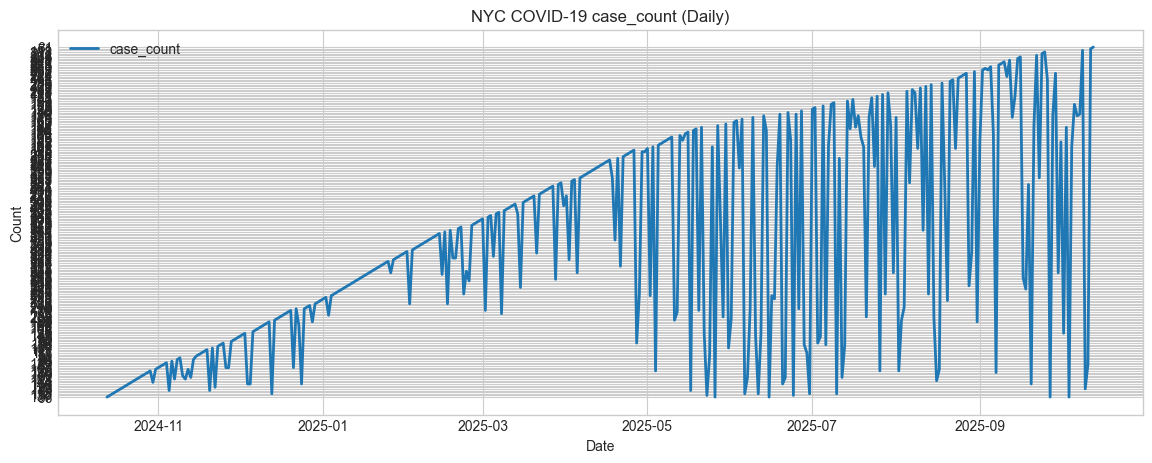

In [34]:
plt.figure(figsize=(14,5))
plt.plot(ts, label=target, linewidth=2)
plt.title(f"NYC COVID-19 {target} (Daily)")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.show()


### Step 5 - Resampling EDA:  Month-end and Yearly totals 

- Use the `.resample()` function to resample the series to month end and yearly 
- Visualize both resampled series 

/var/folders/7n/rj4gbkk13_1f9n1qf54j12gh0000gp/T/ipykernel_23567/1402041084.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  m_end = ts.resample("M").sum()
/var/folders/7n/rj4gbkk13_1f9n1qf54j12gh0000gp/T/ipykernel_23567/1402041084.py:9: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  y_sum = ts.resample("Y").sum()


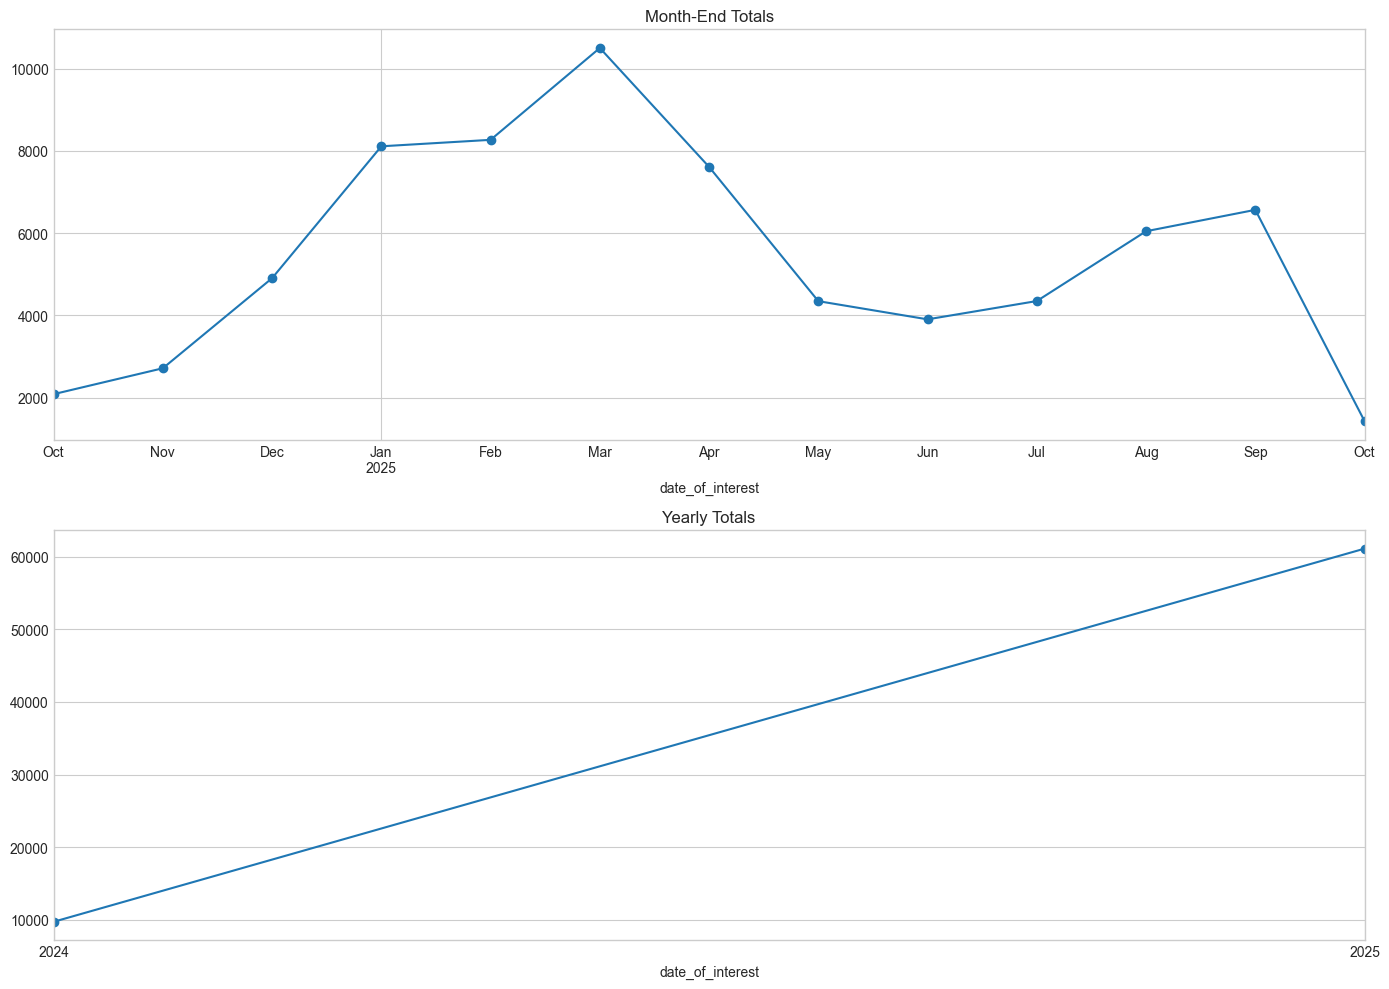

In [35]:
# CELL 5 — Resampling EDA: Month-end and Yearly totals (Pandas-only)

# Month-end totals
ts = pd.to_numeric(ts, errors="coerce").fillna(0)

m_end = ts.resample("M").sum()

# Yearly totals
y_sum = ts.resample("Y").sum()


fig, ax = plt.subplots(2, 1, figsize=(14,10))

m_end.plot(ax=ax[0], marker="o", title="Month-End Totals")
y_sum.plot(ax=ax[1], marker="o", title="Yearly Totals")

plt.tight_layout()
plt.show()


### Step 6 - Decompose the original time series object (use period = 7 since that represents weekly seasonality)
- Make a visual of the decomposition

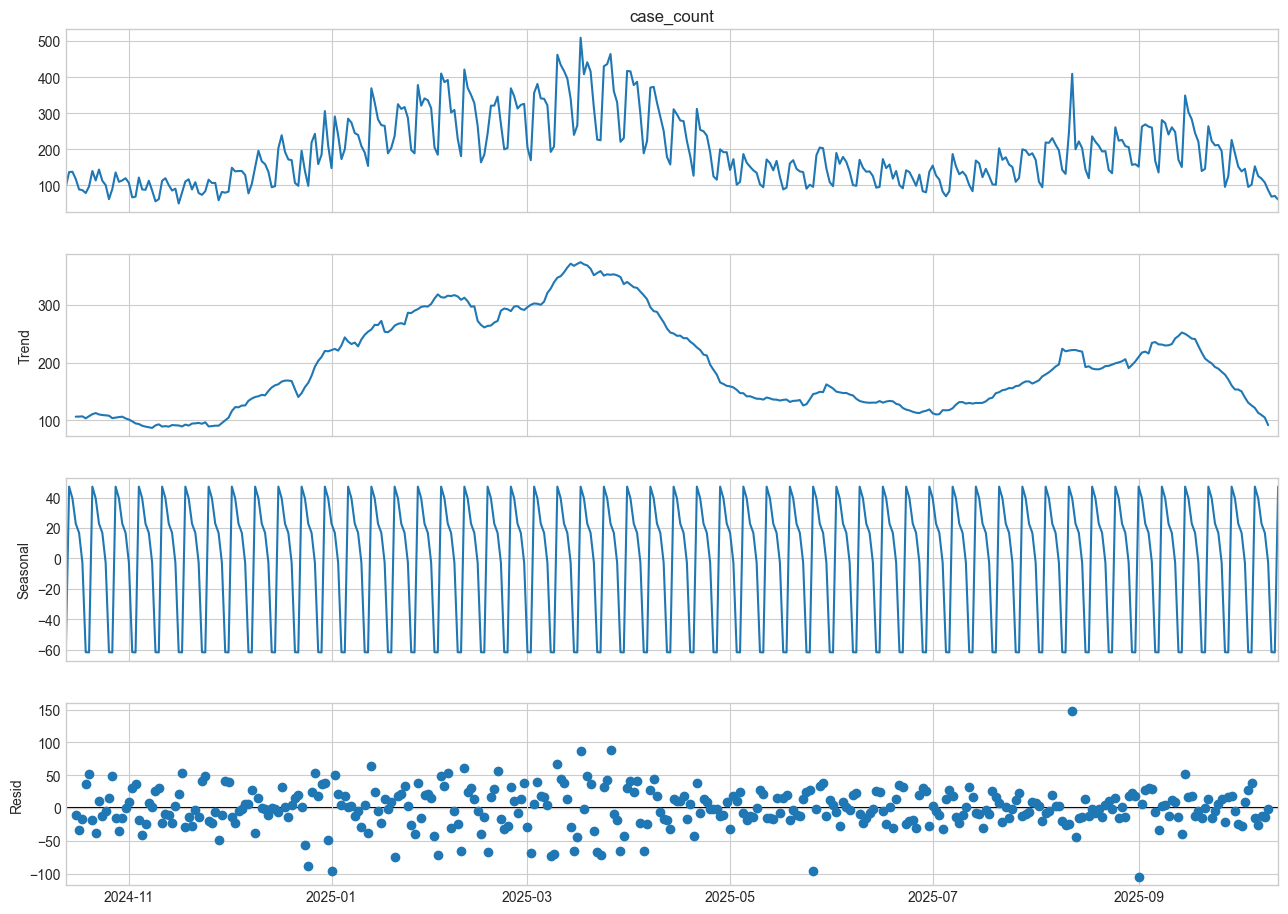

In [36]:
# CELL 6 — Decomposition (weekly seasonality → period=7)
decomp = seasonal_decompose(ts, model="additive", period=7)

fig = decomp.plot()
fig.set_size_inches(14,10)
plt.show()


### Step 7 - Do the ADF test for stationarity on the original time series and for taking a difference of 1 on the time series 
- Be sure to drop missing values (if you didn't above) 

In [37]:
# CELL 7 — ADF stationarity test: raw → difference (1) → (optional) seasonal diff(7)
result_raw = adfuller(ts.dropna())

print("ADF Test — Raw Series")
print(f"ADF Statistic: {result_raw[0]:.4f}")
print(f"p-value: {result_raw[1]:.4f}")

ts_diff1 = ts.diff()

result_diff1 = adfuller(ts_diff1.dropna())

print("\nADF Test — First Difference")
print(f"ADF Statistic: {result_diff1[0]:.4f}")
print(f"p-value: {result_diff1[1]:.4f}")

ts_diff7 = ts.diff(7)

result_diff7 = adfuller(ts_diff7.dropna())

print("\nADF Test — Seasonal Diff (7)")
print(f"ADF Statistic: {result_diff7[0]:.4f}")
print(f"p-value: {result_diff7[1]:.4f}")


ADF Test — Raw Series
ADF Statistic: -1.6001
p-value: 0.4835

ADF Test — First Difference
ADF Statistic: -3.7766
p-value: 0.0032

ADF Test — Seasonal Diff (7)
ADF Statistic: -2.3674
p-value: 0.1512


## We Share — Reflection 

1) **Narrative:** One sentence describing the series over your window (trend + weekly seasonality + volatility).  

Over the most recent 12-month period (October 2024 to October 2025), the NYC daily COVID case counts show a generally slight downward trend, indicating gradual stabilization after earlier years. The series also displays clear weekly seasonality, with counts consistently dropping on weekends due to reduced testing and reporting. While the overall pattern is steady, there are occasional short-lived spikes that create some volatility but do not form any prolonged surge.

2) **Stationarity:** Which transform (if any) produced p < 0.05? Why does that matter before modeling?  

The ADF test shows that the raw series is not stationary (p ≈ 0.48), but applying a first difference makes it stationary (p ≈ 0.003). The seasonal difference did not achieve stationarity. This matters because many time-series models require a stationary series to produce valid, reliable estimates. Without differencing, the underlying trend and seasonal effects would violate model assumptions and lead to misleading forecasts or unstable parameter estimates.

3) **Operational lens:** Based on month-end and yearly views, what **calendar effects** would you brief stakeholders about?

The month-end resampling highlights consistent dips near weekends and holidays, which are driven more by reporting cycles than by actual changes in transmission. Yearly totals suggest that overall COVID activity remains lower and more stable compared to earlier phases of the pandemic. For operational decision-making, stakeholders should be aware that some apparent declines—especially at month-end—reflect calendar effects rather than true epidemiological shifts, and planning or staffing decisions should adjust for these predictable reporting patterns.